In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mart_ticket_modeling.csv")

print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(10000, 52)


,ticket_id,booking_id,issue_category,contact_channel,priority_initial,guest_id,host_id,listing_id,nights,days_until_checkin_at_ticket,...,senior_agent_routing,rebooking_coupon_offered,repeat_contact_probability,repeat_contact_7d,escalation_probability,escalated,resolution_hours,csat_score,poor_csat,long_resolution
0,T000000,B000000,payment_problem,email,high,G00882,H00938,L02865,9,12,...,1,0,0.088,0,0.089,0,4.98,5,0,0
1,T000001,B000001,policy_question,chat,medium,G01659,H00095,L00570,2,2,...,1,0,0.223,0,0.114,0,4.80,5,0,0
2,T000002,B000002,refund_request,chat,medium,G03280,H00088,L01038,8,4,...,1,0,0.265,0,0.122,0,13.65,5,0,0
3,T000003,B000003,refund_request,phone,low,G03348,H01238,L00180,5,7,...,0,1,0.492,1,0.328,0,22.14,4,0,0
4,T000004,B000004,policy_question,chat,low,G03456,H00039,L00952,5,28,...,0,0,0.338,0,0.139,0,2.02,4,0,0


In [5]:
df.isna().mean().sort_values(ascending=False).head(20)

ticket_id                               0.0
booking_id                              0.0
listing_review_score                    0.0
listing_cleanliness_score               0.0
listing_accuracy_score                  0.0
listing_review_count                    0.0
cancellation_policy                     0.0
instant_book_enabled                    0.0
same_week_checkin_flag                  0.0
strict_policy_flag                      0.0
host_cancelled_booking_flag             0.0
high_value_booking_flag                 0.0
sentiment_score                         0.0
urgency_score                           0.0
time_to_first_agent_response_minutes    0.0
message_count_first_30min               0.0
senior_agent_routing                    0.0
rebooking_coupon_offered                0.0
repeat_contact_probability              0.0
repeat_contact_7d                       0.0
dtype: float64

In [6]:
important_cols = [
    "ticket_id",
    "issue_category",
    "contact_channel",
    "priority_initial",
    "days_until_checkin_at_ticket",
    "total_booking_value",
    "sentiment_score",
    "urgency_score",
    "senior_agent_routing",
    "rebooking_coupon_offered",
    "repeat_contact_7d",
    "escalated",
    "csat_score",
    "poor_csat",
    "resolution_hours"
]

df[important_cols].head()

,ticket_id,issue_category,contact_channel,priority_initial,days_until_checkin_at_ticket,total_booking_value,sentiment_score,urgency_score,senior_agent_routing,rebooking_coupon_offered,repeat_contact_7d,escalated,csat_score,poor_csat,resolution_hours
0,T000000,payment_problem,email,high,12,2675.30,-0.166,0.325,1,0,0,0,5,0,4.98
1,T000001,policy_question,chat,medium,2,463.99,0.005,0.468,1,0,0,0,5,0,4.80
2,T000002,refund_request,chat,medium,4,1895.76,-0.018,0.673,1,0,0,0,5,0,13.65
3,T000003,refund_request,phone,low,7,550.32,0.506,0.642,0,1,1,0,4,0,22.14
4,T000004,policy_question,chat,low,28,1499.65,-0.023,0.426,0,0,0,0,4,0,2.02


In [7]:
target_cols = [
    "repeat_contact_7d",
    "escalated",
    "poor_csat",
    "long_resolution",
    "senior_agent_routing",
    "rebooking_coupon_offered"
]

target_summary = df[target_cols].mean().sort_values(ascending=False)

target_summary

repeat_contact_7d           0.3715
senior_agent_routing        0.3224
escalated                   0.2204
rebooking_coupon_offered    0.1516
long_resolution             0.1342
poor_csat                   0.0255
dtype: float64

In [8]:
issue_volume = (
    df["issue_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

issue_volume.columns = ["issue_category", "ticket_share_pct"]
issue_volume

,issue_category,ticket_share_pct
0,refund_request,20.20
1,policy_question,19.42
2,checkin_problem,14.62
3,host_cancellation,14.39
4,listing_not_as_described,13.44
5,payment_problem,12.05
6,safety_issue,5.88


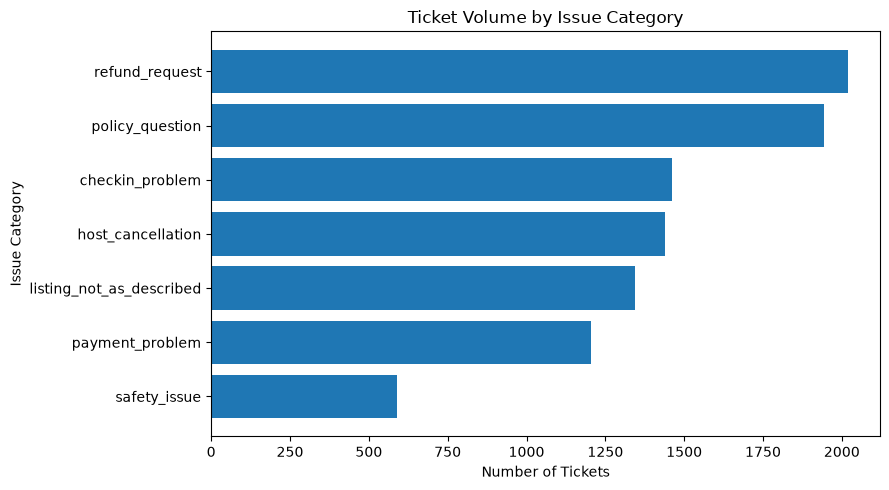

In [9]:
issue_volume_plot = df["issue_category"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
plt.barh(issue_volume_plot.index, issue_volume_plot.values)
plt.title("Ticket Volume by Issue Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Issue Category")
plt.tight_layout()
plt.show()

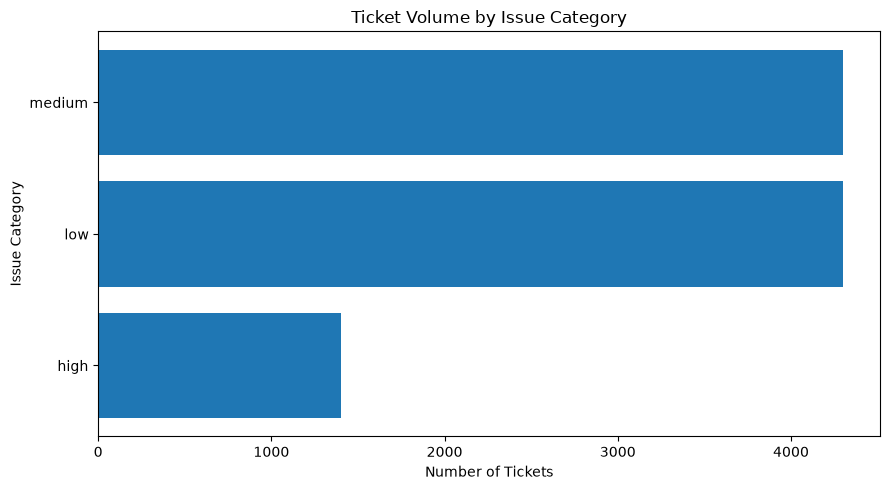

In [10]:
issue_volume_plot = df["priority_initial"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
plt.barh(issue_volume_plot.index, issue_volume_plot.values)
plt.title("Ticket Volume by Issue Category")
plt.xlabel("Number of Tickets")
plt.ylabel("Issue Category")
plt.tight_layout()
plt.show()

In [11]:
repeat_by_issue = (
    df.groupby("issue_category")
    .agg(
        tickets=("ticket_id", "count"),
        repeat_contact_rate=("repeat_contact_7d", "mean"),
        escalation_rate=("escalated", "mean"),
        poor_csat_rate=("poor_csat", "mean"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_csat=("csat_score", "mean")
    )
    .sort_values("repeat_contact_rate", ascending=False)
)

repeat_by_issue

,tickets,repeat_contact_rate,escalation_rate,poor_csat_rate,avg_resolution_hours,avg_csat
issue_category,,,,,,
safety_issue,588,0.729592,0.688776,0.076531,24.407653,3.522109
host_cancellation,1439,0.556637,0.286310,0.031967,14.714621,3.949270
listing_not_as_described,1344,0.360119,0.191964,0.029018,13.096518,4.115327
policy_question,1942,0.308960,0.163234,0.014418,12.508908,4.221421
refund_request,2020,0.308416,0.159901,0.021287,12.308787,4.200990
checkin_problem,1462,0.303694,0.188782,0.022572,12.601190,4.174419
payment_problem,1205,0.277178,0.176763,0.017427,11.579851,4.234025


In [12]:
display_table = repeat_by_issue.copy()

for col in ["repeat_contact_rate", "escalation_rate", "poor_csat_rate"]:
    display_table[col] = (display_table[col] * 100).round(2).astype(str) + "%"

display_table["avg_resolution_hours"] = display_table["avg_resolution_hours"].round(2)
display_table["avg_csat"] = display_table["avg_csat"].round(2)

display_table

,tickets,repeat_contact_rate,escalation_rate,poor_csat_rate,avg_resolution_hours,avg_csat
issue_category,,,,,,
safety_issue,588,72.96%,68.88%,7.65%,24.41,3.52
host_cancellation,1439,55.66%,28.63%,3.2%,14.71,3.95
listing_not_as_described,1344,36.01%,19.2%,2.9%,13.10,4.12
policy_question,1942,30.9%,16.32%,1.44%,12.51,4.22
refund_request,2020,30.84%,15.99%,2.13%,12.31,4.20
checkin_problem,1462,30.37%,18.88%,2.26%,12.60,4.17
payment_problem,1205,27.72%,17.68%,1.74%,11.58,4.23


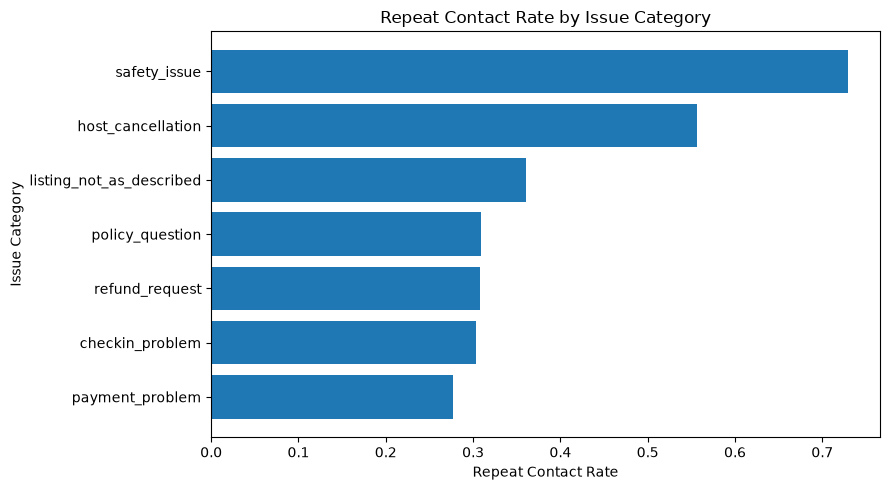

In [13]:
plot_data = repeat_by_issue["repeat_contact_rate"].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(plot_data.index, plot_data.values)
plt.title("Repeat Contact Rate by Issue Category")
plt.xlabel("Repeat Contact Rate")
plt.ylabel("Issue Category")
plt.tight_layout()
plt.show()

In [14]:
escalation_by_issue = (
    df.groupby("issue_category")["escalated"]
    .mean()
    .sort_values(ascending=False)
)

(escalation_by_issue * 100).round(2)

issue_category
safety_issue                68.88
host_cancellation           28.63
listing_not_as_described    19.20
checkin_problem             18.88
payment_problem             17.68
policy_question             16.32
refund_request              15.99
Name: escalated, dtype: float64

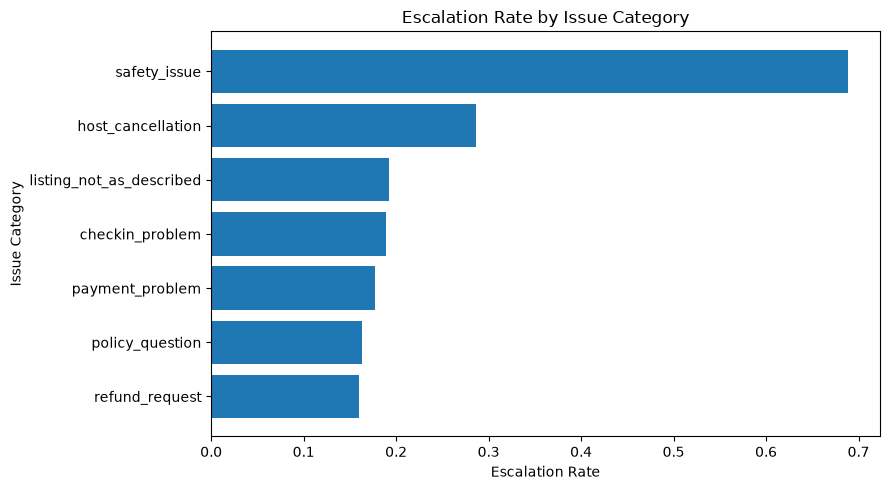

In [15]:
plot_data = escalation_by_issue.sort_values()

plt.figure(figsize=(9, 5))
plt.barh(plot_data.index, plot_data.values)
plt.title("Escalation Rate by Issue Category")
plt.xlabel("Escalation Rate")
plt.ylabel("Issue Category")
plt.tight_layout()
plt.show()

In [16]:
csat_by_issue = (
    df.groupby("issue_category")
    .agg(
        avg_csat=("csat_score", "mean"),
        poor_csat_rate=("poor_csat", "mean"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
    .sort_values("avg_csat")
)

csat_by_issue

,avg_csat,poor_csat_rate,avg_resolution_hours
issue_category,,,
safety_issue,3.522109,0.076531,24.407653
host_cancellation,3.949270,0.031967,14.714621
listing_not_as_described,4.115327,0.029018,13.096518
checkin_problem,4.174419,0.022572,12.601190
refund_request,4.200990,0.021287,12.308787
policy_question,4.221421,0.014418,12.508908
payment_problem,4.234025,0.017427,11.579851


In [17]:
df[["urgency_score", "sentiment_score", "repeat_contact_7d", "escalated", "csat_score"]].corr()

,urgency_score,sentiment_score,repeat_contact_7d,escalated,csat_score
urgency_score,1.000000,-0.294942,0.283737,0.211568,-0.209032
sentiment_score,-0.294942,1.000000,-0.230374,-0.168244,0.179401
repeat_contact_7d,0.283737,-0.230374,1.000000,0.230765,-0.680771
escalated,0.211568,-0.168244,0.230765,1.000000,-0.489374
csat_score,-0.209032,0.179401,-0.680771,-0.489374,1.000000


In [18]:
df["urgency_bucket"] = pd.qcut(
    df["urgency_score"],
    q=5,
    labels=["very_low", "low", "medium", "high", "very_high"]
)

urgency_analysis = (
    df.groupby("urgency_bucket", observed=True)
    .agg(
        tickets=("ticket_id", "count"),
        repeat_contact_rate=("repeat_contact_7d", "mean"),
        escalation_rate=("escalated", "mean"),
        avg_csat=("csat_score", "mean")
    )
)

urgency_analysis

,tickets,repeat_contact_rate,escalation_rate,avg_csat
urgency_bucket,,,,
very_low,2002,0.223277,0.148851,4.294705
low,2014,0.274578,0.153923,4.237339
medium,1997,0.331998,0.186279,4.164246
high,1997,0.429644,0.239359,4.054582
very_high,1990,0.600000,0.374874,3.833668


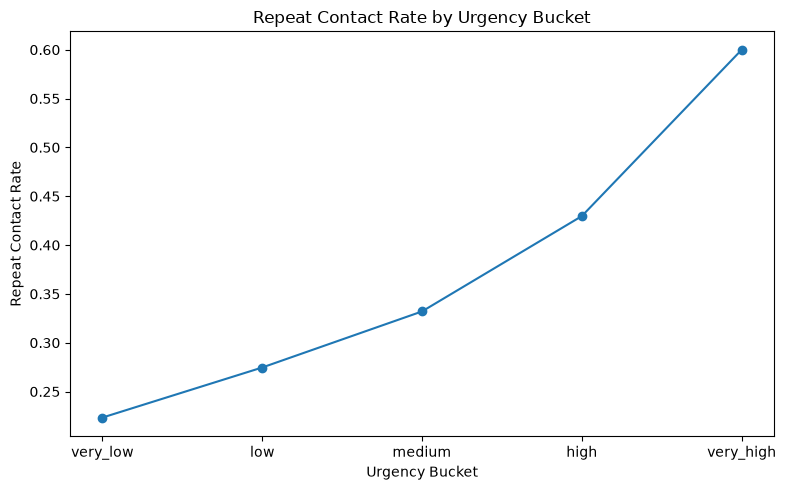

In [19]:
plot_data = urgency_analysis["repeat_contact_rate"]

plt.figure(figsize=(8, 5))
plt.plot(plot_data.index.astype(str), plot_data.values, marker="o")
plt.title("Repeat Contact Rate by Urgency Bucket")
plt.xlabel("Urgency Bucket")
plt.ylabel("Repeat Contact Rate")
plt.tight_layout()
plt.show()

In [20]:
df.head()

,ticket_id,booking_id,issue_category,contact_channel,priority_initial,guest_id,host_id,listing_id,nights,days_until_checkin_at_ticket,...,rebooking_coupon_offered,repeat_contact_probability,repeat_contact_7d,escalation_probability,escalated,resolution_hours,csat_score,poor_csat,long_resolution,urgency_bucket
0,T000000,B000000,payment_problem,email,high,G00882,H00938,L02865,9,12,...,0,0.088,0,0.089,0,4.98,5,0,0,low
1,T000001,B000001,policy_question,chat,medium,G01659,H00095,L00570,2,2,...,0,0.223,0,0.114,0,4.80,5,0,0,medium
2,T000002,B000002,refund_request,chat,medium,G03280,H00088,L01038,8,4,...,0,0.265,0,0.122,0,13.65,5,0,0,very_high
3,T000003,B000003,refund_request,phone,low,G03348,H01238,L00180,5,7,...,1,0.492,1,0.328,0,22.14,4,0,0,high
4,T000004,B000004,policy_question,chat,low,G03456,H00039,L00952,5,28,...,0,0.338,0,0.139,0,2.02,4,0,0,medium


In [21]:
treatment_check = (
    df.groupby("senior_agent_routing")
    .agg(
        tickets=("ticket_id", "count"),
        avg_urgency=("urgency_score", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        same_week_rate=("same_week_checkin_flag", "mean"),
        safety_issue_rate=("issue_category", lambda x: (x == "safety_issue").mean()),
        host_cancellation_rate=("issue_category", lambda x: (x == "host_cancellation").mean()),
        repeat_contact_rate=("repeat_contact_7d", "mean"),
        escalation_rate=("escalated", "mean"),
        avg_csat=("csat_score", "mean"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
)

treatment_check

,tickets,avg_urgency,avg_sentiment,same_week_rate,safety_issue_rate,host_cancellation_rate,repeat_contact_rate,escalation_rate,avg_csat,avg_resolution_hours
senior_agent_routing,,,,,,,,,,
0,6776,0.431181,-0.213944,0.194510,0.025531,0.105224,0.371606,0.210153,4.060508,13.463073
1,3224,0.537402,-0.308791,0.263648,0.128722,0.225186,0.371278,0.241935,4.236973,13.472298


In [22]:
formatted = treatment_check.copy()

pct_cols = [
    "same_week_rate",
    "safety_issue_rate",
    "host_cancellation_rate",
    "repeat_contact_rate",
    "escalation_rate"
]

for col in pct_cols:
    formatted[col] = (formatted[col] * 100).round(2).astype(str) + "%"

for col in ["avg_urgency", "avg_sentiment", "avg_csat", "avg_resolution_hours"]:
    formatted[col] = formatted[col].round(2)

formatted

,tickets,avg_urgency,avg_sentiment,same_week_rate,safety_issue_rate,host_cancellation_rate,repeat_contact_rate,escalation_rate,avg_csat,avg_resolution_hours
senior_agent_routing,,,,,,,,,,
0,6776,0.43,-0.21,19.45%,2.55%,10.52%,37.16%,21.02%,4.06,13.46
1,3224,0.54,-0.31,26.36%,12.87%,22.52%,37.13%,24.19%,4.24,13.47


In [23]:
raw_treatment_effect = (
    df.groupby("senior_agent_routing")
    .agg(
        repeat_contact_rate=("repeat_contact_7d", "mean"),
        escalation_rate=("escalated", "mean"),
        poor_csat_rate=("poor_csat", "mean"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
)

raw_treatment_effect

,repeat_contact_rate,escalation_rate,poor_csat_rate,avg_resolution_hours
senior_agent_routing,,,,
0,0.371606,0.210153,0.031287,13.463073
1,0.371278,0.241935,0.013337,13.472298


In [24]:
root_cause_table = (
    df.groupby("issue_category")
    .agg(
        ticket_share=("ticket_id", "count"),
        repeat_contacts=("repeat_contact_7d", "sum"),
        escalations=("escalated", "sum"),
        poor_csat_cases=("poor_csat", "sum"),
        avg_urgency=("urgency_score", "mean"),
        avg_resolution_hours=("resolution_hours", "mean")
    )
)

root_cause_table["ticket_share_pct"] = (
    root_cause_table["ticket_share"] / root_cause_table["ticket_share"].sum()
)

root_cause_table["repeat_contact_share_pct"] = (
    root_cause_table["repeat_contacts"] / root_cause_table["repeat_contacts"].sum()
)

root_cause_table["escalation_share_pct"] = (
    root_cause_table["escalations"] / root_cause_table["escalations"].sum()
)

root_cause_table = root_cause_table.sort_values(
    "repeat_contact_share_pct",
    ascending=False
)

root_cause_table

,ticket_share,repeat_contacts,escalations,poor_csat_cases,avg_urgency,avg_resolution_hours,ticket_share_pct,repeat_contact_share_pct,escalation_share_pct
issue_category,,,,,,,,,
host_cancellation,1439,801,412,46,0.636492,14.714621,0.1439,0.215612,0.186933
refund_request,2020,623,323,43,0.408200,12.308787,0.2020,0.167699,0.146552
policy_question,1942,600,317,28,0.422864,12.508908,0.1942,0.161507,0.143829
listing_not_as_described,1344,484,258,39,0.410166,13.096518,0.1344,0.130283,0.117060
checkin_problem,1462,444,276,33,0.405127,12.601190,0.1462,0.119515,0.125227
safety_issue,588,429,405,45,0.786733,24.407653,0.0588,0.115478,0.183757
payment_problem,1205,334,213,21,0.403679,11.579851,0.1205,0.089906,0.096642


In [25]:
business_table = root_cause_table.copy()

for col in ["ticket_share_pct", "repeat_contact_share_pct", "escalation_share_pct"]:
    business_table[col] = (business_table[col] * 100).round(2).astype(str) + "%"

business_table["avg_urgency"] = business_table["avg_urgency"].round(2)
business_table["avg_resolution_hours"] = business_table["avg_resolution_hours"].round(2)

business_table

,ticket_share,repeat_contacts,escalations,poor_csat_cases,avg_urgency,avg_resolution_hours,ticket_share_pct,repeat_contact_share_pct,escalation_share_pct
issue_category,,,,,,,,,
host_cancellation,1439,801,412,46,0.64,14.71,14.39%,21.56%,18.69%
refund_request,2020,623,323,43,0.41,12.31,20.2%,16.77%,14.66%
policy_question,1942,600,317,28,0.42,12.51,19.42%,16.15%,14.38%
listing_not_as_described,1344,484,258,39,0.41,13.10,13.44%,13.03%,11.71%
checkin_problem,1462,444,276,33,0.41,12.60,14.62%,11.95%,12.52%
safety_issue,588,429,405,45,0.79,24.41,5.88%,11.55%,18.38%
payment_problem,1205,334,213,21,0.40,11.58,12.05%,8.99%,9.66%


In [26]:
print("EDA Summary")
print("-" * 60)

print(f"Total tickets: {len(df):,}")
print(f"Repeat contact rate: {df['repeat_contact_7d'].mean():.2%}")
print(f"Escalation rate: {df['escalated'].mean():.2%}")
print(f"Poor CSAT rate: {df['poor_csat'].mean():.2%}")
print(f"Long resolution rate: {df['long_resolution'].mean():.2%}")

top_repeat_issue = repeat_by_issue.index[0]
top_escalation_issue = escalation_by_issue.index[0]
lowest_csat_issue = csat_by_issue.index[0]

print()
print(f"Highest repeat-contact issue: {top_repeat_issue}")
print(f"Highest escalation issue: {top_escalation_issue}")
print(f"Lowest CSAT issue: {lowest_csat_issue}")

print()
print("Inference warning:")
print(
    "Senior routing is not randomly assigned. "
    "It is more common for urgent and severe cases, so raw treated-vs-control comparison is biased."
)

EDA Summary
------------------------------------------------------------
Total tickets: 10,000
Repeat contact rate: 37.15%
Escalation rate: 22.04%
Poor CSAT rate: 2.55%
Long resolution rate: 13.42%

Highest repeat-contact issue: safety_issue
Highest escalation issue: safety_issue
Lowest CSAT issue: safety_issue

Inference warning:
Senior routing is not randomly assigned. It is more common for urgent and severe cases, so raw treated-vs-control comparison is biased.
